# PFN + BNNPrior showcase, x_dim=2 (M2)

The x_dim=1 version (`pfn_prior_overlay_showcase.ipynb`) overlays the PFN's predictive density directly on an (x, y) heatmap -- that trick needs y as its own axis, so it doesn't generalize to x_dim=2, where (x1, x2) already fill the plane. This notebook is the 2D-search-space diagnostic instead: "does the PFN's posterior look reasonable" via two complementary views over the same [0,1]^2 grid --

1. **Heatmap panels** (`plot_prior_data_and_pfn_2d_heatmaps`) -- true function, posterior mean, |mean - true| error, posterior std, side by side. This is the primary "is this reasonable" check: four flat, directly-comparable 2D images beat one 3D plot for a quick gut check, since nothing is occluded or angle-dependent.
2. **3D posterior surface** (`plot_pfn_posterior_2d_surface`) -- posterior median as an opaque surface with translucent quantile surfaces above/below (a "confidence tube"), train data scattered at their observed (x1, x2, y). More intuitive for seeing the *shape* of the uncertainty at a glance, but a static PNG is one fixed camera angle -- treat it as illustrative, not the primary diagnostic.

Background:
- `src/anytimeacquisition/models/pfn.py`, `src/anytimeacquisition/models/bar_distribution.py`, `src/anytimeacquisition/pipelines/train_pfn.py`
- `src/anytimeacquisition/priors/bnn.py`'s own `plot_2d_environments` -- the true-function-only heatmap convention these panels extend with the PFN's posterior
- `docs/milestones/M2.md` -- checklist this notebook is showcasing


In [11]:
import torch

from anytimeacquisition.pipelines.train_pfn import (
    plot_pfn_posterior_2d_surface,
    plot_prior_data_and_pfn_2d_heatmaps,
    train_pfn,
)

torch.manual_seed(0)
PRIOR_KWARGS = dict(ecdf_n_draws=50, ecdf_samples_per_draw=300, cache_dir=None)


## Get a model: train fresh, or load a pretrained checkpoint

Two ways to get a `(model, bar_dist)` pair for the views below -- toggle `USE_PRETRAINED`:
- `False` (default): trains a small/fast smoke-scale run inline, same shape as the 1D notebook (not the real M2 checkpoint -- see `docs/milestones/M2.md` for what a serious run should look like; `experiment=pfn_smoke_xdim2` via the Hydra pipeline is the reproducible, provenance-tracked equivalent). ~300 steps is enough for `eval_mse` to visibly drop and the panels below to look sane; it is not enough for a tight fit.
- `True`: loads `models/pfn_ulysses_real.pt` via `load_pfn_checkpoint` -- the genuinely-sized x_dim=2 run from `experiment=pfn_ulysses_real` (`configs/experiment/pfn_ulysses_real.yaml`, 5000 steps, d_model=256/6 layers), a real trained posterior rather than a few-hundred-step smoke fit. `load_pfn_checkpoint` asserts the checkpoint's `model_state` matches `PFN(**ckpt["config"])` (the PFN owns its own `bar_dist` as a submodule now, see `models/pfn.py`); swap in any other `models/*.pt` checkpoint's path the same way, as long as it was trained at `x_dim=2` -- these panels don't generalize to other input dims (see the module docstring above).

In [12]:
USE_PRETRAINED = True

if USE_PRETRAINED:
    from anytimeacquisition.utils.paths import CHECKPOINT_DIR
    from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint

    checkpoint_path = CHECKPOINT_DIR / "pfn_ulysses_real.pt"
    model, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
    assert ckpt["config"]["x_dim"] == 2, (
        f"{checkpoint_path.name} was trained at x_dim={ckpt['config']['x_dim']}, "
        "but these panels are x_dim=2 only -- see the module docstring above."
    )
    print(f"loaded PFN checkpoint: {checkpoint_path.name}, config={ckpt['config']}")
else:
    result = train_pfn(
        x_dim=2,
        d_model=64, n_heads=4, n_layers=3, d_ff=128, n_bins=64,
        batch_size=32, min_train=3, max_train=20, n_test=10,
        n_steps=300, log_every=50,
        prior_kwargs=PRIOR_KWARGS,
    )
    model, bar_dist = result["model"], result["bar_dist"]

loaded PFN checkpoint: pfn_ulysses_real.pt, config={'x_dim': 2, 'd_model': 256, 'n_heads': 8, 'n_layers': 6, 'd_ff': 512, 'n_bins': 128}


## View 1: heatmap panels

True function, PFN posterior mean, |mean - true| error, and posterior std, all over the same [0,1]^2 grid, train points overlaid (white dots). Read it as: does the mean panel visually track the true panel; is the error panel low near train points and higher in unexplored regions; does the std panel shrink near data and stay wide in gaps (the "confidence" the PFN should have learned, same idea as a GP posterior variance).

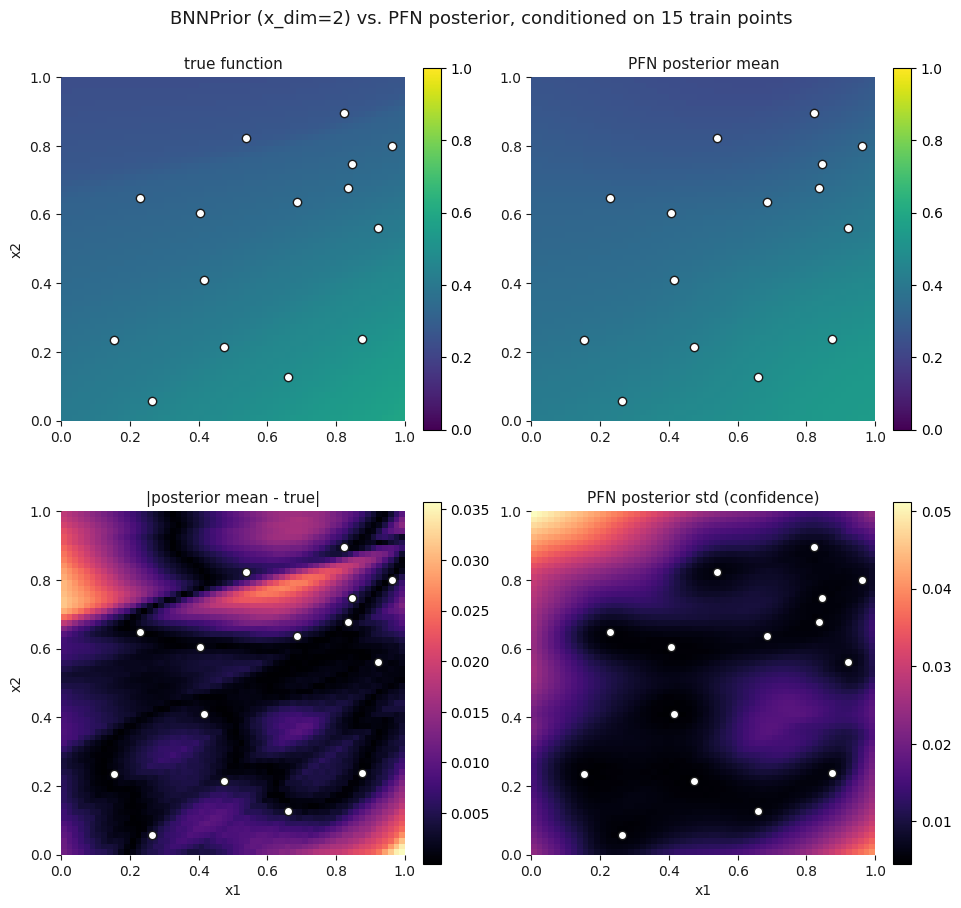

In [13]:
_ = plot_prior_data_and_pfn_2d_heatmaps(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=15, seed=11)


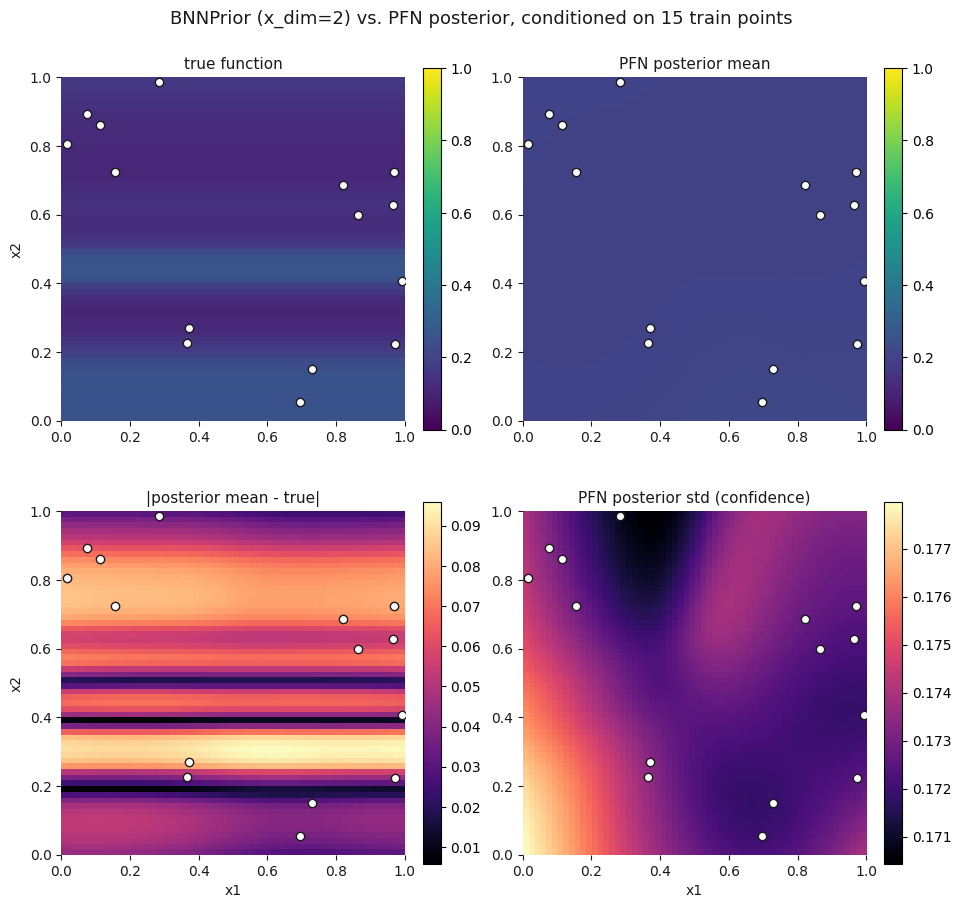

In [7]:
_ = plot_prior_data_and_pfn_2d_heatmaps(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=15, seed=27)


### Effect of context size

Same environment (fixed seed), more train points -- the std panel should visibly tighten and the error panel should shrink as context grows, mirroring the 1D notebook's entropy-vs-context-size check.

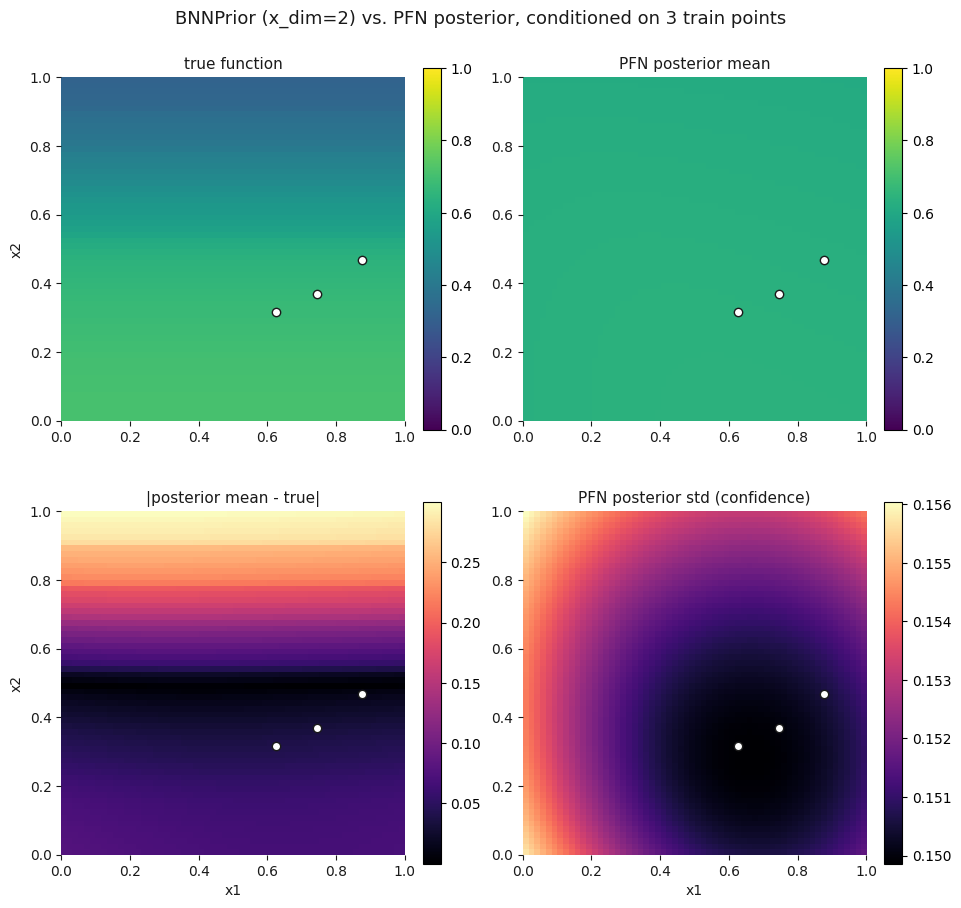

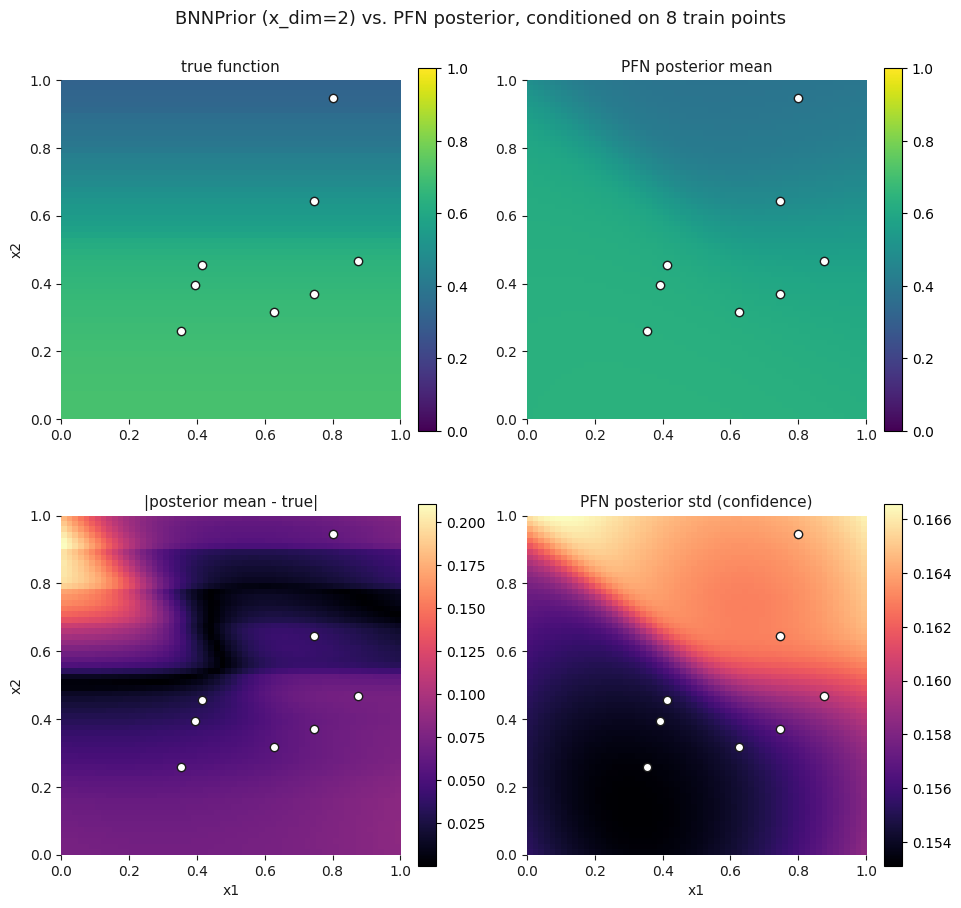

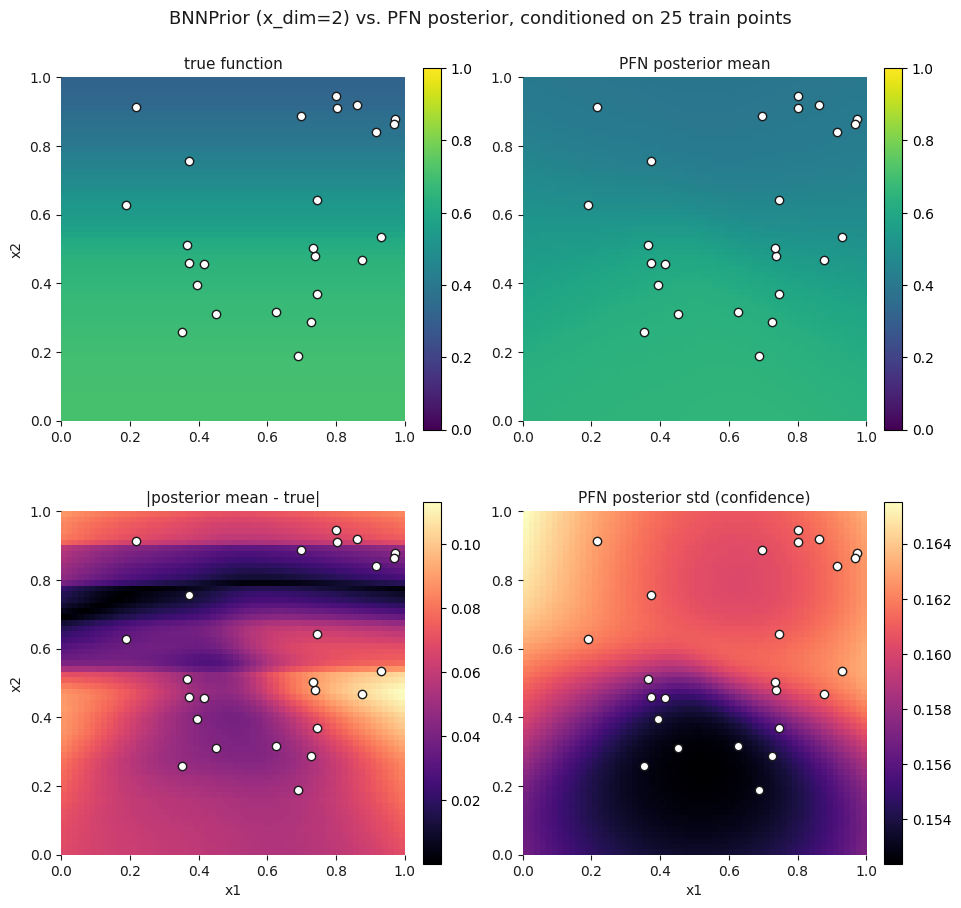

In [8]:
for n_train in (3, 8, 25):
    plot_prior_data_and_pfn_2d_heatmaps(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=n_train, seed=42)


## View 2: 3D posterior surface

The same posterior, viewed as a surface: the median as an opaque colored sheet, the 10%/90% quantiles as translucent sheets above/below it, train data scattered at its observed height. This is the "3D plot with interesting quantiles + posterior mean" shape -- useful for building intuition about how the uncertainty tube wraps around the data, but a single static angle can hide as much as it shows, so cross-check anything surprising here against the heatmap panels above.

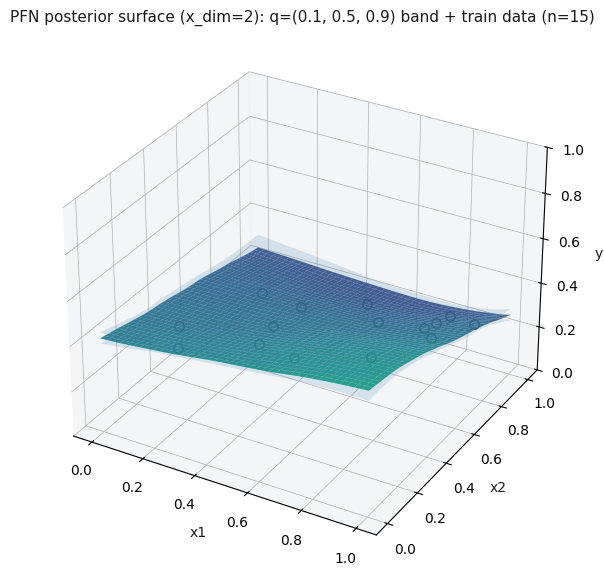

In [14]:
_ = plot_pfn_posterior_2d_surface(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=15, quantiles=(0.1, 0.5, 0.9), seed=11)


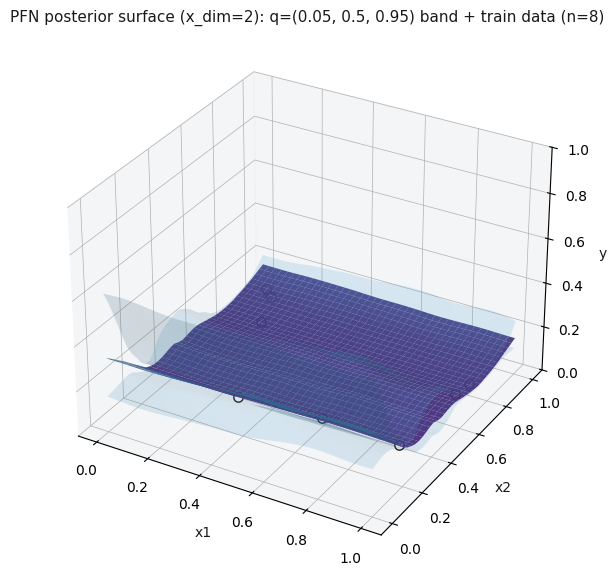

In [15]:
_ = plot_pfn_posterior_2d_surface(model, bar_dist, prior_kwargs=PRIOR_KWARGS, n_train=8, quantiles=(0.05, 0.5, 0.95), seed=27)
